# Cluster Experiments (Feature-Based)

This notebook provides an end-to-end clustering workflow for vessel silhouette features.

It includes:
- feature loading and cleaning
- weighted preprocessing (including lower weight for `t*`/`b*`)
- interchangeable clustering methods
- evaluation metrics and size diagnostics
- density plots by cluster
- stacked outline visualization per cluster

In [2]:
import sys
print(sys.executable)

/Users/oliviakasmin/Desktop/okasmin-parsons-thesis-2026/.venv/bin/python


In [3]:
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA

In [4]:
# ---- Paths / defaults ----
REPO_ROOT = Path.cwd().resolve()
FEATURE_CSV = REPO_ROOT / "process_data/features/silhouette_features.csv"
REAL_IMAGES_DIR = REPO_ROOT / "process_data/generated/real_images"

# Sampling / weighting defaults
TOP_BOTTOM_WEIGHT = 0.35  # downweight t*/b* vs other feature groups
LR_WEIGHT = 1.0
SHAPE_WEIGHT = 1.0
INNER_WEIGHT = 1.0

# clustering defaults
DEFAULT_METHOD = "agglomerative"  # agglomerative | kmeans | dbscan
DEFAULT_N_CLUSTERS = 20
DEFAULT_LINKAGE = "ward"  # ward | average | complete | single
DEFAULT_RANDOM_STATE = 42

FEATURE_CSV, REAL_IMAGES_DIR

(PosixPath('/Users/oliviakasmin/Desktop/okasmin-parsons-thesis-2026/hf_space/pipeline/features/silhouette_features.csv'),
 PosixPath('/Users/oliviakasmin/Desktop/okasmin-parsons-thesis-2026/hf_space/pipeline/real_images'))

In [5]:
def load_feature_table(feature_csv: Path) -> pd.DataFrame:
    df = pd.read_csv(feature_csv)
    df["object_id"] = df["object_id"].astype(str)
    return df


def get_feature_groups(df: pd.DataFrame):
    # Explicit feature selection to avoid accidental prefix collisions (e.g., bbox_*).
    lr_cols = [c for c in df.columns if c.startswith("l") and c[1:].isdigit()]
    lr_cols += [c for c in df.columns if c.startswith("r") and c[1:].isdigit()]

    tb_cols = [c for c in df.columns if c.startswith("t") and c[1:].isdigit()]
    tb_cols += [c for c in df.columns if c.startswith("b") and c[1:].isdigit()]

    symmetry_cols = [
        c
        for c in [
            "lr_profile_abs_diff_mean",
            "eccentricity",
            "upper_vs_lower_width_ratio",
            "centroid_x_norm",
            "centroid_offset_x",
        ]
        if c in df.columns
    ]

    contour_cols = [
        c
        for c in df.columns
        if c.startswith("contour_") or c.startswith("convexity_")
    ]
    hu_cols = [c for c in df.columns if c.startswith("hu") and c[2:].isdigit()]
    inner_cols = [c for c in df.columns if c.startswith("inner")]

    # Keep non-inner shape features together.
    shape_cols = list(dict.fromkeys(contour_cols + hu_cols + symmetry_cols))

    # Guardrail: only keep numeric columns in all groups.
    def only_numeric(cols):
        return [c for c in cols if pd.api.types.is_numeric_dtype(df[c])]

    groups = {
        "lr": only_numeric(lr_cols),
        "tb": only_numeric(tb_cols),
        "shape": only_numeric(shape_cols),
        "inner": only_numeric(inner_cols),
    }
    return groups


def build_weighted_matrix(
    df: pd.DataFrame,
    groups: dict,
    lr_weight: float = LR_WEIGHT,
    tb_weight: float = TOP_BOTTOM_WEIGHT,
    shape_weight: float = SHAPE_WEIGHT,
    inner_weight: float = INNER_WEIGHT,
):
    # Use a deterministic feature order by group.
    cols = groups["lr"] + groups["tb"] + groups["shape"] + groups["inner"]
    X = df[cols].copy()

    # impute missing numeric values
    imputer = SimpleImputer(strategy="median")
    X_imp = imputer.fit_transform(X)

    # standardize before weighting
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_imp)

    # per-column weights
    weights = []
    for c in cols:
        if c in groups["lr"]:
            weights.append(lr_weight)
        elif c in groups["tb"]:
            weights.append(tb_weight)
        elif c in groups["inner"]:
            weights.append(inner_weight)
        else:
            weights.append(shape_weight)

    W = np.array(weights, dtype=float)
    X_weighted = X_scaled * W

    return X_weighted, cols, imputer, scaler, W

In [6]:
def fit_clusters(
    X: np.ndarray,
    method: str = DEFAULT_METHOD,
    n_clusters: int = DEFAULT_N_CLUSTERS,
    linkage: str = DEFAULT_LINKAGE,
    random_state: int = DEFAULT_RANDOM_STATE,
    dbscan_eps: float = 3.5,
    dbscan_min_samples: int = 8,
):
    method = method.lower().strip()

    if method == "kmeans":
        model = KMeans(n_clusters=n_clusters, random_state=random_state, n_init="auto")
        labels = model.fit_predict(X)
    elif method == "agglomerative":
        model = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage)
        labels = model.fit_predict(X)
    elif method == "dbscan":
        model = DBSCAN(eps=dbscan_eps, min_samples=dbscan_min_samples)
        labels = model.fit_predict(X)
    else:
        raise ValueError(f"Unsupported method: {method}")

    return model, labels


def evaluate_labels(X: np.ndarray, labels: np.ndarray) -> dict:
    labels = np.asarray(labels)
    unique = sorted(set(labels.tolist()))
    non_noise = [u for u in unique if u != -1]

    metrics = {
        "n_rows": int(X.shape[0]),
        "n_features": int(X.shape[1]),
        "n_clusters_excluding_noise": len(non_noise),
        "n_noise": int(np.sum(labels == -1)),
    }

    # For silhouette/CH/DB we need >=2 clusters and no single-cluster collapse.
    eval_mask = labels != -1
    eval_labels = labels[eval_mask]
    eval_X = X[eval_mask]

    if len(set(eval_labels.tolist())) >= 2 and eval_X.shape[0] > len(set(eval_labels.tolist())):
        metrics["silhouette"] = float(silhouette_score(eval_X, eval_labels))
        metrics["calinski_harabasz"] = float(calinski_harabasz_score(eval_X, eval_labels))
        metrics["davies_bouldin"] = float(davies_bouldin_score(eval_X, eval_labels))
    else:
        metrics["silhouette"] = math.nan
        metrics["calinski_harabasz"] = math.nan
        metrics["davies_bouldin"] = math.nan

    return metrics


def attach_labels(df: pd.DataFrame, labels: np.ndarray) -> pd.DataFrame:
    out = df.copy()
    out["cluster"] = labels
    return out

In [7]:
def plot_cluster_sizes(df_labeled: pd.DataFrame):
    counts = df_labeled["cluster"].value_counts().sort_index()
    plt.figure(figsize=(10, 4))
    counts.plot(kind="bar")
    plt.title("Cluster Size Distribution")
    plt.xlabel("cluster")
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()


def plot_feature_density_by_cluster(
    df_labeled: pd.DataFrame,
    feature: str,
    clusters=None,
    max_clusters: int = 8,
    bins: int = 60,
):
    data = df_labeled.copy()
    if clusters is None:
        ordered = data["cluster"].value_counts().index.tolist()
        clusters = ordered[:max_clusters]

    plt.figure(figsize=(10, 5))
    for cluster_id in clusters:
        s = data.loc[data["cluster"] == cluster_id, feature].dropna()
        if len(s) == 0:
            continue
        plt.hist(s, bins=bins, alpha=0.3, density=True, label=f"cluster {cluster_id}")

    plt.title(f"Density by Cluster: {feature}")
    plt.xlabel(feature)
    plt.ylabel("density")
    plt.legend(loc="best", fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_pca_projection(X: np.ndarray, labels: np.ndarray, title: str = "PCA Cluster Projection"):
    pca = PCA(n_components=2, random_state=42)
    points = pca.fit_transform(X)

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(points[:, 0], points[:, 1], c=labels, s=10, cmap="tab20", alpha=0.8)
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.colorbar(scatter, label="cluster")
    plt.tight_layout()
    plt.show()

In [8]:
def _outline_path_for_object_id(object_id: str, real_images_dir: Path) -> Path:
    return real_images_dir / f"{object_id}_outline.png"


def stack_cluster_outlines(
    df_labeled: pd.DataFrame,
    cluster_id: int,
    real_images_dir: Path = REAL_IMAGES_DIR,
    max_images: int | None = None,
    alpha_per_image: float = 0.08,
    normalize_each: bool = True,
):
    cluster_rows = df_labeled[df_labeled["cluster"] == cluster_id]
    if max_images is not None:
        cluster_rows = cluster_rows.head(max_images)

    outline_arrays = []
    for oid in cluster_rows["object_id"].astype(str).tolist():
        p = _outline_path_for_object_id(oid, real_images_dir)
        if not p.exists():
            continue
        img = Image.open(p).convert("RGBA")
        arr = np.array(img, dtype=np.float32)

        # use alpha as primary signal for outline intensity
        alpha = arr[:, :, 3] / 255.0
        if normalize_each:
            m = alpha.max()
            if m > 0:
                alpha = alpha / m
        outline_arrays.append(alpha)

    if not outline_arrays:
        print(f"No outline images found for cluster {cluster_id}")
        return None

    stack = np.zeros_like(outline_arrays[0], dtype=np.float32)
    for alpha in outline_arrays:
        stack += alpha_per_image * alpha

    stack = np.clip(stack, 0.0, 1.0)

    plt.figure(figsize=(6, 6))
    plt.imshow(stack, cmap="magma")
    plt.title(f"Stacked Outlines - Cluster {cluster_id} (n={len(outline_arrays)})")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    return stack

Method: agglomerative
Rows: 3888 Features used: 297
{'n_rows': 3888, 'n_features': 297, 'n_clusters_excluding_noise': 20, 'n_noise': 0, 'silhouette': 0.07604254071343373, 'calinski_harabasz': 279.66050071804676, 'davies_bouldin': 2.2413660592213587}


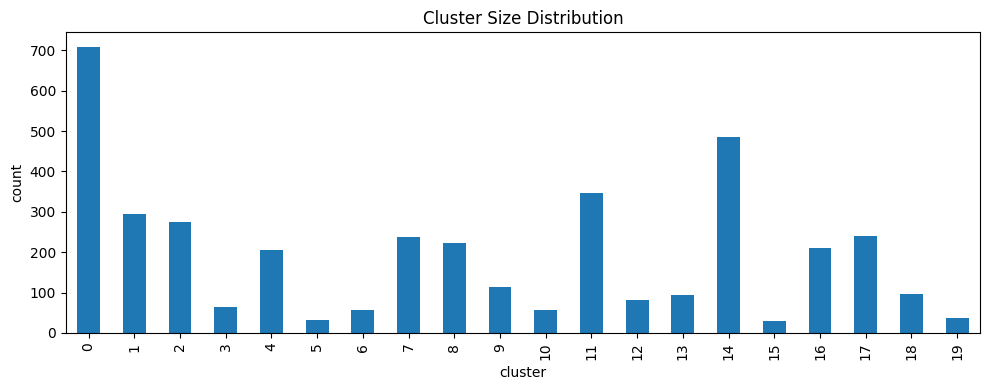

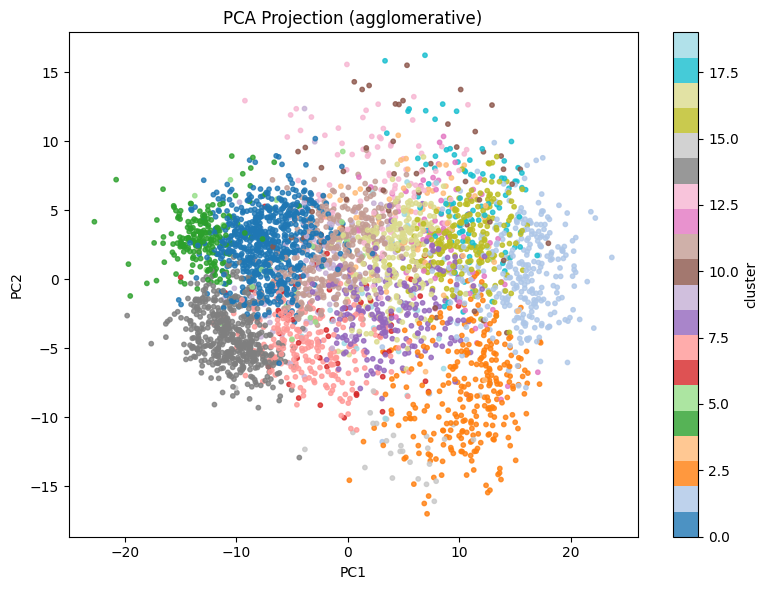

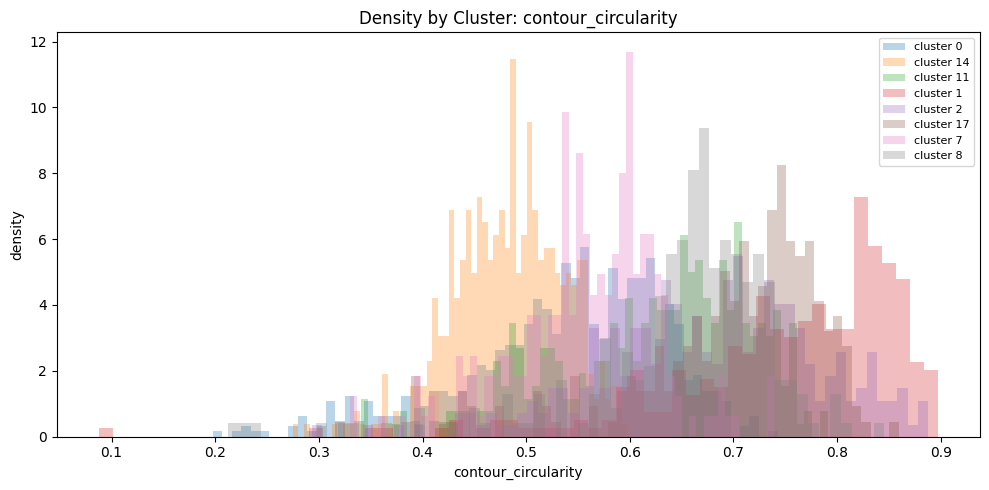

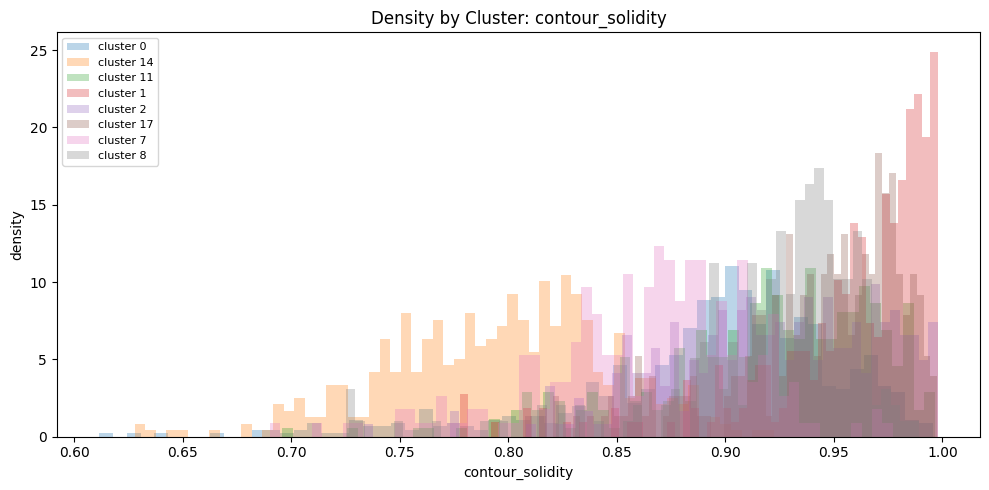

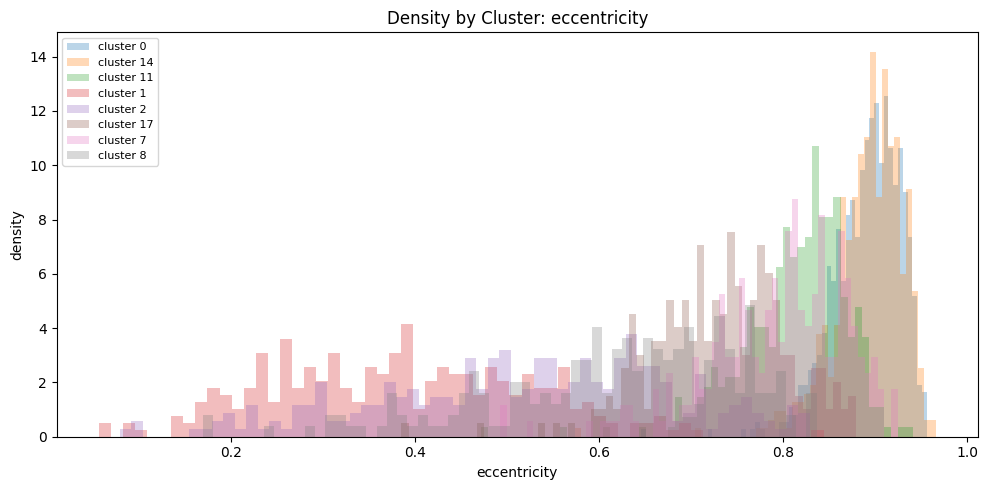

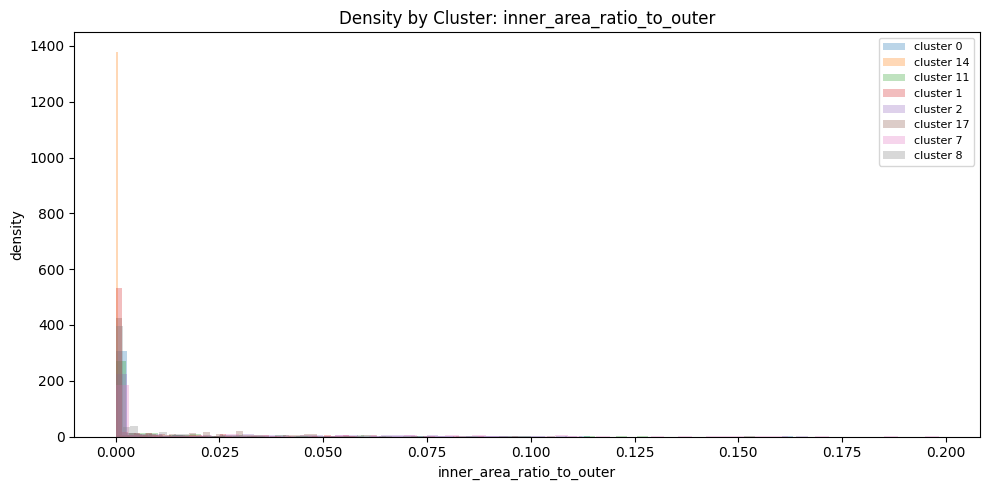

In [9]:
# ---- Main experiment cell (edit params and re-run) ----
METHOD = "agglomerative"    # "agglomerative" | "kmeans" | "dbscan"
N_CLUSTERS = 20
LINKAGE = "ward"

# Feature weighting
LR_W = 1.0
TB_W = 0.35
SHAPE_W = 1.0
INNER_W = 1.0

# DBSCAN-only (ignored for others)
DBSCAN_EPS = 3.5
DBSCAN_MIN_SAMPLES = 8

# Load / preprocess
df = load_feature_table(FEATURE_CSV)
groups = get_feature_groups(df)
X, used_cols, imputer, scaler, W = build_weighted_matrix(
    df,
    groups,
    lr_weight=LR_W,
    tb_weight=TB_W,
    shape_weight=SHAPE_W,
    inner_weight=INNER_W,
)

# Fit + evaluate
model, labels = fit_clusters(
    X,
    method=METHOD,
    n_clusters=N_CLUSTERS,
    linkage=LINKAGE,
    dbscan_eps=DBSCAN_EPS,
    dbscan_min_samples=DBSCAN_MIN_SAMPLES,
)
metrics = evaluate_labels(X, labels)
df_labeled = attach_labels(df, labels)

print("Method:", METHOD)
print("Rows:", len(df_labeled), "Features used:", len(used_cols))
print(metrics)

plot_cluster_sizes(df_labeled)
plot_pca_projection(X, labels, title=f"PCA Projection ({METHOD})")

# Example density plots
for f in ["contour_circularity", "contour_solidity", "eccentricity", "inner_area_ratio_to_outer"]:
    if f in df_labeled.columns:
        plot_feature_density_by_cluster(df_labeled, f, max_clusters=8)

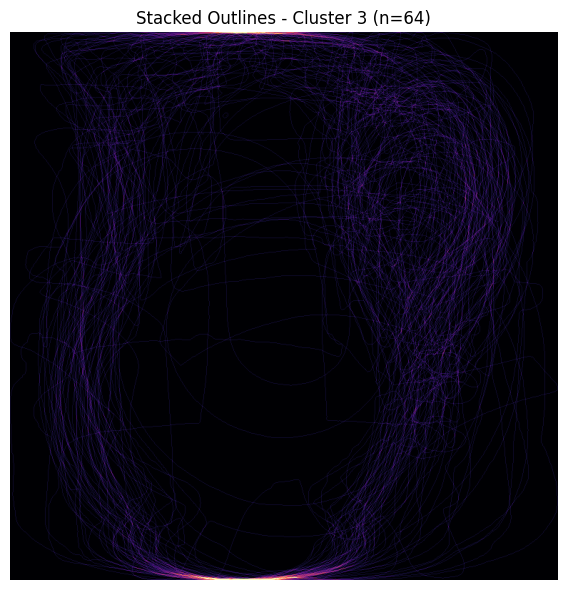

cluster=3, n=64
sample object IDs:
['185914', '188994', '193355', '194292', '194471', '194488', '194624', '194644', '195307', '197552', '197605', '197614', '197616', '198426', '198432', '199134', '199195', '199238', '199285', '199320', '199338', '199415', '199417', '199515', '199568', '199570', '199751', '199886', '201054', '201716', '201758', '201781', '204070', '204072', '204098', '207713', '208006', '208245', '208387', '208409']


In [14]:
# ---- Cluster inspection helpers ----

# Pick a cluster to inspect visually
CLUSTER_TO_VIEW = 3
MAX_STACK_IMAGES = None  # e.g. 150 for faster rendering

_ = stack_cluster_outlines(
    df_labeled,
    cluster_id=CLUSTER_TO_VIEW,
    real_images_dir=REAL_IMAGES_DIR,
    max_images=MAX_STACK_IMAGES,
    alpha_per_image=0.08,
)

# Show sample IDs from the cluster
sample_ids = df_labeled.loc[df_labeled["cluster"] == CLUSTER_TO_VIEW, "object_id"].astype(str).head(40).tolist()
print(f"cluster={CLUSTER_TO_VIEW}, n={len(df_labeled[df_labeled['cluster']==CLUSTER_TO_VIEW])}")
print("sample object IDs:")
print(sample_ids)

In [11]:
# ---- Optional method sweep (quick compare) ----
# Runs a small grid so you can compare metrics quickly.

experiments = [
    {"method": "agglomerative", "n_clusters": 16, "linkage": "ward", "tb_weight": 0.35},
    {"method": "agglomerative", "n_clusters": 20, "linkage": "ward", "tb_weight": 0.35},
    {"method": "kmeans", "n_clusters": 16, "linkage": "ward", "tb_weight": 0.35},
    {"method": "kmeans", "n_clusters": 20, "linkage": "ward", "tb_weight": 0.35},
]

results = []
for exp in experiments:
    X_exp, _, _, _, _ = build_weighted_matrix(
        df,
        groups,
        lr_weight=1.0,
        tb_weight=exp["tb_weight"],
        shape_weight=1.0,
        inner_weight=1.0,
    )
    _, labels_exp = fit_clusters(
        X_exp,
        method=exp["method"],
        n_clusters=exp["n_clusters"],
        linkage=exp["linkage"],
    )
    m = evaluate_labels(X_exp, labels_exp)
    results.append({**exp, **m})

pd.DataFrame(results).sort_values(by=["silhouette", "calinski_harabasz"], ascending=[False, False])

,method,n_clusters,linkage,tb_weight,n_rows,n_features,n_clusters_excluding_noise,n_noise,silhouette,calinski_harabasz,davies_bouldin
3,kmeans,20,ward,0.35,3888,297,20,0,0.107360,326.148212,2.025496
2,kmeans,16,ward,0.35,3888,297,16,0,0.102686,379.006392,2.137462
0,agglomerative,16,ward,0.35,3888,297,16,0,0.082180,325.948943,2.181805
1,agglomerative,20,ward,0.35,3888,297,20,0,0.076043,279.660501,2.241366


## 12-Group Strategy: Outlier Bucket + 11 Inlier Clusters

This section implements:
1. Outlier detection (DBSCAN) to create a dedicated outlier bucket.
2. Agglomerative clustering on inliers into 11 groups.
3. Combined final labels (12 groups total target: 11 inlier groups + 1 outlier group).
4. Compactness diagnostics to verify at least 6-9 tightly aligned groups.

In [ ]:
def split_outliers_dbscan(X: np.ndarray, eps: float = 3.5, min_samples: int = 8):
    model = DBSCAN(eps=eps, min_samples=min_samples)
    labels = model.fit_predict(X)
    inlier_mask = labels != -1
    return model, labels, inlier_mask


def cluster_inliers_agglomerative(
    X: np.ndarray,
    inlier_mask: np.ndarray,
    n_clusters_inliers: int = 11,
    linkage: str = "ward",
):
    inlier_idx = np.where(inlier_mask)[0]
    X_in = X[inlier_mask]

    model = AgglomerativeClustering(n_clusters=n_clusters_inliers, linkage=linkage)
    inlier_labels = model.fit_predict(X_in)

    # Final labels: map inliers to 0..n_clusters_inliers-1 and outliers to outlier_label.
    final_labels = np.full(X.shape[0], fill_value=-1, dtype=int)
    final_labels[inlier_idx] = inlier_labels
    outlier_label = n_clusters_inliers
    final_labels[~inlier_mask] = outlier_label

    return model, inlier_labels, final_labels, outlier_label


def compute_cluster_compactness(X: np.ndarray, labels: np.ndarray, exclude_labels=None):
    exclude = set(exclude_labels or [])
    rows = []

    for cluster_id in sorted(set(labels.tolist())):
        if cluster_id in exclude:
            continue
        idx = np.where(labels == cluster_id)[0]
        if len(idx) == 0:
            continue
        Xc = X[idx]
        centroid = Xc.mean(axis=0)
        dists = np.linalg.norm(Xc - centroid, axis=1)
        rows.append(
            {
                "cluster": int(cluster_id),
                "size": int(len(idx)),
                "mean_dist_to_centroid": float(np.mean(dists)),
                "median_dist_to_centroid": float(np.median(dists)),
                "p90_dist_to_centroid": float(np.percentile(dists, 90)),
            }
        )

    out = pd.DataFrame(rows)
    if len(out) > 0:
        out = out.sort_values(by=["mean_dist_to_centroid", "p90_dist_to_centroid", "size"], ascending=[True, True, False])
    return out

In [ ]:
# ---- Run 12-group strategy ----

# You can tune these
OUTLIER_EPS = 3.5
OUTLIER_MIN_SAMPLES = 8
INLIER_CLUSTERS = 11
LINKAGE_12 = "ward"

# Rebuild weighted matrix from current weights for consistency with prior section
X12, cols12, *_ = build_weighted_matrix(
    df,
    groups,
    lr_weight=LR_W,
    tb_weight=TB_W,
    shape_weight=SHAPE_W,
    inner_weight=INNER_W,
)

_, outlier_labels_raw, inlier_mask = split_outliers_dbscan(
    X12,
    eps=OUTLIER_EPS,
    min_samples=OUTLIER_MIN_SAMPLES,
)

agg_model_12, inlier_labels_12, final_labels_12, OUTLIER_LABEL = cluster_inliers_agglomerative(
    X12,
    inlier_mask=inlier_mask,
    n_clusters_inliers=INLIER_CLUSTERS,
    linkage=LINKAGE_12,
)

# attach to dataframe
_df12 = attach_labels(df, final_labels_12)

print("Outlier label:", OUTLIER_LABEL)
print("Outlier count:", int((final_labels_12 == OUTLIER_LABEL).sum()))
print("Inlier count:", int((final_labels_12 != OUTLIER_LABEL).sum()))
print("Total groups in final labels:", len(set(final_labels_12.tolist())))

metrics_12_all = evaluate_labels(X12, final_labels_12)
print("Overall metrics (including outlier bucket as cluster):")
print(metrics_12_all)

plot_cluster_sizes(_df12)
plot_pca_projection(X12, final_labels_12, title="12-group strategy (11 inlier clusters + outlier bucket)")

df_12 = _df12  # expose a convenient dataframe variable for later cells

In [ ]:
# ---- Compactness diagnostics + cluster inspection ----

compactness = compute_cluster_compactness(X12, final_labels_12, exclude_labels=[OUTLIER_LABEL])
display(compactness)

# If you want 6-9 very tight groups, inspect the top compact clusters:
TOP_TIGHT_N = 8
tight_clusters = compactness.head(TOP_TIGHT_N)["cluster"].tolist() if len(compactness) else []
print(f"Top {TOP_TIGHT_N} tight clusters:", tight_clusters)

# Visualize stacked outlines for top tight clusters
for cid in tight_clusters[:6]:  # keep output manageable
    _ = stack_cluster_outlines(df_12, cluster_id=int(cid), real_images_dir=REAL_IMAGES_DIR, max_images=None, alpha_per_image=0.08)

# Optional: inspect outlier bucket stack
_ = stack_cluster_outlines(df_12, cluster_id=int(OUTLIER_LABEL), real_images_dir=REAL_IMAGES_DIR, max_images=300, alpha_per_image=0.06)

In [ ]:
# ---- Feature inclusion audit ----

groups = get_feature_groups(df)

feature_audit = pd.DataFrame({"feature": used_cols, "weight": W})
feature_audit["group"] = feature_audit["feature"].map(
    lambda c: "lr"
    if c in groups["lr"]
    else "tb"
    if c in groups["tb"]
    else "inner"
    if c in groups["inner"]
    else "shape"
)

print("Group sizes:")
print({k: len(v) for k, v in groups.items()})

# Quick check for accidental columns that should not be in clustering.
unexpected_prefixes = [c for c in used_cols if c.startswith("bbox_") or c in {"mask_width", "mask_height", "valid_row_count", "valid_col_count"}]
print("Unexpected in-use columns:", unexpected_prefixes)

display(feature_audit)